In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import koreanize_matplotlib

In [55]:
df = pd.read_csv('avocado.csv')
df.head()

,Unnamed: 0,Date,AveragePrice,Total Volume,4046,4225,4770,Total Bags,Small Bags,Large Bags,XLarge Bags,type,year,region
0,0,2015-12-27,1.33,64236.62,1036.74,54454.85,48.16,8696.87,8603.62,93.25,0.0,conventional,2015,Albany
1,1,2015-12-20,1.35,54876.98,674.28,44638.81,58.33,9505.56,9408.07,97.49,0.0,conventional,2015,Albany
2,2,2015-12-13,0.93,118220.22,794.70,109149.67,130.50,8145.35,8042.21,103.14,0.0,conventional,2015,Albany
3,3,2015-12-06,1.08,78992.15,1132.00,71976.41,72.58,5811.16,5677.40,133.76,0.0,conventional,2015,Albany
4,4,2015-11-29,1.28,51039.60,941.48,43838.39,75.78,6183.95,5986.26,197.69,0.0,conventional,2015,Albany


In [58]:
df['Date'].unique()

array(['2015-12-27', '2015-12-20', '2015-12-13', '2015-12-06',
       '2015-11-29', '2015-11-22', '2015-11-15', '2015-11-08',
       '2015-11-01', '2015-10-25', '2015-10-18', '2015-10-11',
       '2015-10-04', '2015-09-27', '2015-09-20', '2015-09-13',
       '2015-09-06', '2015-08-30', '2015-08-23', '2015-08-16',
       '2015-08-09', '2015-08-02', '2015-07-26', '2015-07-19',
       '2015-07-12', '2015-07-05', '2015-06-28', '2015-06-21',
       '2015-06-14', '2015-06-07', '2015-05-31', '2015-05-24',
       '2015-05-17', '2015-05-10', '2015-05-03', '2015-04-26',
       '2015-04-19', '2015-04-12', '2015-04-05', '2015-03-29',
       '2015-03-22', '2015-03-15', '2015-03-08', '2015-03-01',
       '2015-02-22', '2015-02-15', '2015-02-08', '2015-02-01',
       '2015-01-25', '2015-01-18', '2015-01-11', '2015-01-04',
       '2016-12-25', '2016-12-18', '2016-12-11', '2016-12-04',
       '2016-11-27', '2016-11-20', '2016-11-13', '2016-11-06',
       '2016-10-30', '2016-10-23', '2016-10-16', '2016-

In [67]:
df['type'].unique()

array(['conventional', 'organic'], dtype=object)

In [59]:
df['Month'] = pd.to_datetime(df['Date']).dt.month

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18249 entries, 0 to 18248
Data columns (total 15 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Unnamed: 0    18249 non-null  int64  
 1   Date          18249 non-null  object 
 2   AveragePrice  18249 non-null  float64
 3   Total Volume  18249 non-null  float64
 4   4046          18249 non-null  float64
 5   4225          18249 non-null  float64
 6   4770          18249 non-null  float64
 7   Total Bags    18249 non-null  float64
 8   Small Bags    18249 non-null  float64
 9   Large Bags    18249 non-null  float64
 10  XLarge Bags   18249 non-null  float64
 11  type          18249 non-null  object 
 12  year          18249 non-null  int64  
 13  region        18249 non-null  object 
 14  volume_by_y   4 non-null      float64
dtypes: float64(10), int64(2), object(3)
memory usage: 2.1+ MB


* 판매량과 가격 
* 생산연도별 판매량 및 가격 (꺽은선 비교)
* 생산월별 판매량 및 가격(계절이 영향을 끼치는지) (꺽은선 비교)
* 크기별 판매량 및 가격 (막대로 비교)
* 지역별 판매량 및 가격 (막대로 비교)
* 타입별 판매량 및 가격(막대로 비교)
* 판매형태별 판매량 및 가격(막대로 비교)

In [7]:
df.groupby('region').sum()

,Unnamed: 0,Date,AveragePrice,Total Volume,4046,4225,4770,Total Bags,Small Bags,Large Bags,XLarge Bags,type,year
region,,,,,,,,,,,,,
Albany,8192,2015-12-272015-12-202015-12-132015-12-062015-1...,527.63,1.606780e+07,6.165396e+05,1.271597e+07,5.503733e+04,2.680255e+06,2.246945e+06,3.898817e+05,43429.16,conventionalconventionalconventionalconvention...,681458
Atlanta,8192,2015-12-272015-12-202015-12-132015-12-062015-1...,452.23,8.860512e+07,4.938750e+07,1.055186e+07,1.052484e+05,2.856051e+07,1.744274e+07,1.083968e+07,278101.68,conventionalconventionalconventionalconvention...,681458
BaltimoreWashington,8192,2015-12-272015-12-202015-12-132015-12-062015-1...,518.57,1.347139e+08,1.205180e+07,8.314222e+07,4.213755e+06,3.530615e+07,3.411761e+07,9.815468e+05,206985.36,conventionalconventionalconventionalconvention...,681458
Boise,8192,2015-12-272015-12-202015-12-132015-12-062015-1...,455.67,1.441319e+07,6.766594e+06,1.170049e+06,1.077134e+06,5.399412e+06,4.677933e+06,7.110283e+05,10449.34,conventionalconventionalconventionalconvention...,681458
Boston,8192,2015-12-272015-12-202015-12-132015-12-062015-1...,517.44,9.727398e+07,1.688178e+06,7.240631e+07,1.684016e+06,2.149548e+07,1.991043e+07,1.500167e+06,84879.99,conventionalconventionalconventionalconvention...,681458
BuffaloRochester,8192,2015-12-272015-12-202015-12-132015-12-062015-1...,512.69,2.296247e+07,6.005149e+05,1.070242e+07,4.878556e+04,1.161075e+07,1.026843e+07,1.260419e+06,81901.94,conventionalconventionalconventionalconvention...,681458
California,8192,2015-12-272015-12-202015-12-132015-12-062015-1...,471.62,1.028982e+09,3.989670e+08,3.514914e+08,3.184105e+07,2.466822e+08,2.290977e+08,1.231194e+07,5272577.91,conventionalconventionalconventionalconvention...,681458
Charlotte,8192,2015-12-272015-12-202015-12-132015-12-062015-1...,542.84,3.555554e+07,7.563811e+06,1.238027e+07,3.913522e+06,1.169794e+07,1.064385e+07,9.844872e+05,69603.59,conventionalconventionalconventionalconvention...,681458
Chicago,8192,2015-12-272015-12-202015-12-132015-12-062015-1...,526.19,1.337023e+08,1.084408e+07,8.602744e+07,1.996539e+07,1.686540e+07,1.479465e+07,1.691875e+06,378872.71,conventionalconventionalconventionalconvention...,681458


In [8]:
df.isnull().sum()

Unnamed: 0      0
Date            0
AveragePrice    0
Total Volume    0
4046            0
4225            0
4770            0
Total Bags      0
Small Bags      0
Large Bags      0
XLarge Bags     0
type            0
year            0
region          0
dtype: int64

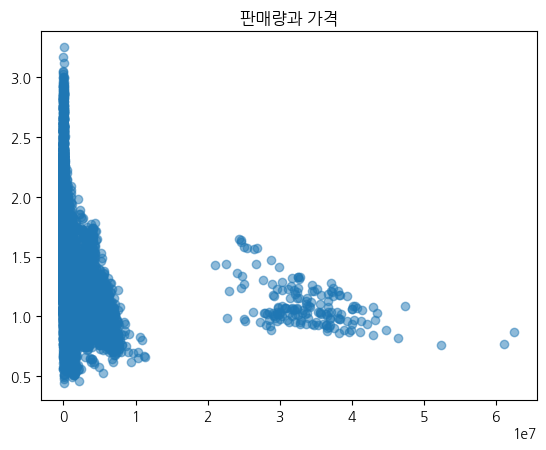

In [12]:
#판매량과 가격
plt.scatter(df['Total Volume'], df['AveragePrice'], alpha=0.5)
plt.title('판매량과 가격')
plt.show()

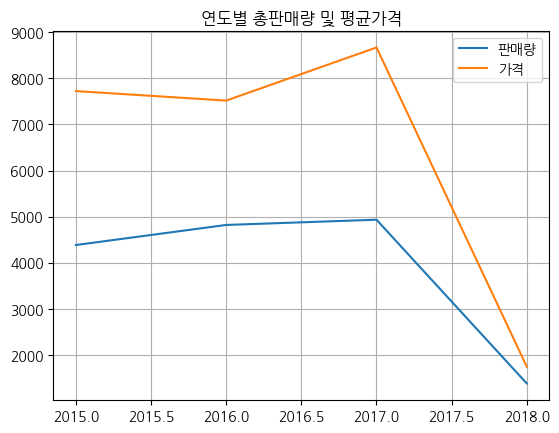

In [65]:
#생산연도별 판매량 및 가격 (꺽은선 비교)
Volume_by_y = df.groupby('year')['Total Volume'].sum()/1000000
Price_by_y = df.groupby('year')['AveragePrice'].sum()
plt.plot(Volume_by_y.index, Volume_by_y.values, label='판매량')
plt.plot(Price_by_y.index, Price_by_y.values, label='가격')
plt.title('연도별 총판매량 및 평균가격')
plt.grid(True)
plt.legend()
plt.show()

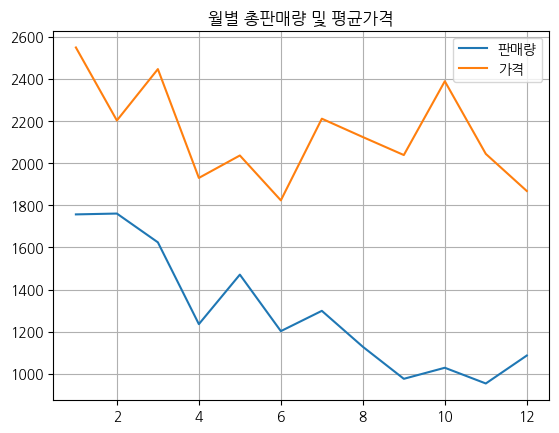

In [63]:
#생산월별 판매량 및 가격(계절이 영향을 끼치는지) (꺽은선 비교)

Volume_by_m = df.groupby('Month')['Total Volume'].sum()/1000000
Price_by_m = df.groupby('Month')['AveragePrice'].sum()
plt.plot(Volume_by_m.index, Volume_by_m.values, label='판매량')
plt.plot(Price_by_m.index, Price_by_m.values, label='가격')
plt.title('월별 총판매량 및 평균가격')
plt.grid(True)
plt.legend()
plt.show()

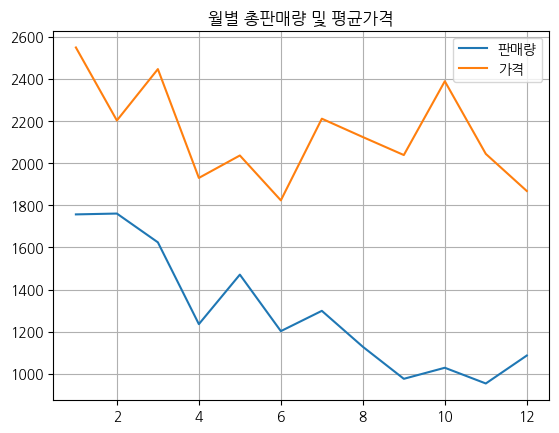

In [64]:
#생산월별 판매량 및 가격(계절이 영향을 끼치는지) (꺽은선 비교)

Volume_by_m = df.groupby(df['Month'])['Total Volume'].sum()/1000000
Price_by_m = df.groupby(df['Month'])['AveragePrice'].sum()
plt.plot(Volume_by_m.index, Volume_by_m.values, label='판매량')
plt.plot(Price_by_m.index, Price_by_m.values, label='가격')
plt.title('월별 총판매량 및 평균가격')
plt.grid(True)
plt.legend()
plt.show()

In [ ]:
#타입별 판매량 및 가격(막대로 비교)
